# Chapter 10
# Image Classification and Object Detection

---

## **Part I: Image Classification**

### With Vision Transformer (ViT)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

C:\Users\sandi\anaconda3\envs\torch-gpu\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sandi\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicted Class: Egyptian cat


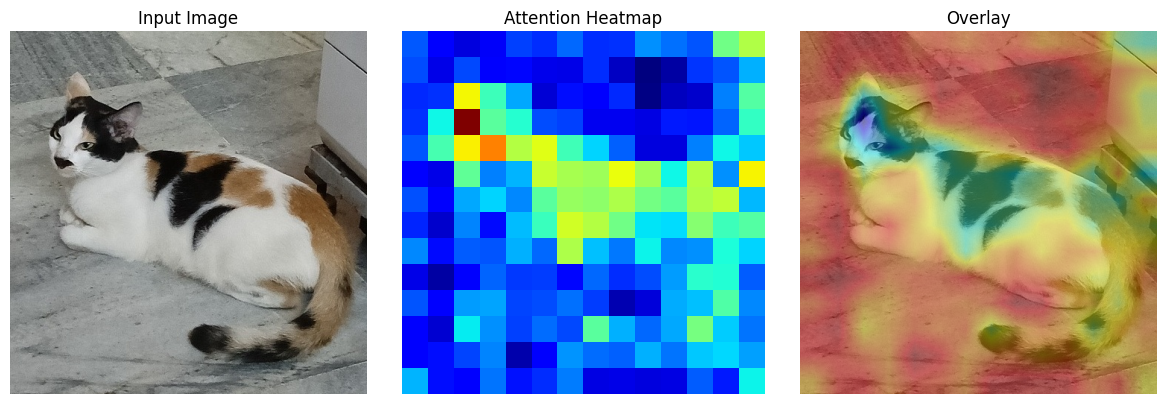

In [1]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

# Load image
image_path = "images/cat.jpg"
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

logits = outputs.logits
attentions = outputs.attentions   # tuple: (layers, batch, heads, tokens, tokens)

# -----------------------------
# 1. Get CLS attention rollout
# -----------------------------
def rollout_attention(attentions):
    # attentions: list of layers
    result = torch.eye(attentions[0].shape[-1])

    for attn in attentions:
        attn_heads_fused = attn.mean(dim=1)[0]  # average heads
        attn_heads_fused += torch.eye(attn_heads_fused.shape[-1])  # residual
        attn_heads_fused /= attn_heads_fused.sum(dim=-1, keepdim=True)

        result = torch.matmul(attn_heads_fused, result)

    # CLS token is index 0
    mask = result[0, 1:]
    return mask

mask = rollout_attention(attentions)

# -----------------------------
# 2. Reshape to patch grid
# -----------------------------
num_patches = mask.shape[0]
grid_size = int(np.sqrt(num_patches))

heatmap = mask.reshape(grid_size, grid_size).cpu().numpy()

# Normalize
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

# -----------------------------
# 3. Resize heatmap to image
# -----------------------------
img = np.array(image)
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

# -----------------------------
# 4. Prediction
# -----------------------------
pred_class = logits.argmax(-1).item()
label = model.config.id2label[pred_class]

print("Predicted Class:", label)

# -----------------------------
# 5. Show result
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Attention Heatmap")
plt.imshow(heatmap, cmap="jet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

### Flower Classification

In [ ]:
import gradio as gr
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForImageClassification

FLOWER_LABELS = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells",
    "sweet pea", "english marigold", "tiger lily", "moon orchid",
    "bird of paradise", "monkshood", "globe thistle", "snapdragon",
    "colt's foot", "king protea", "spear thistle", "yellow iris",
    "globe flower", "purple coneflower", "peruvian lily",
    "balloon flower", "giant white arum lily", "fire lily",
    "pincushion flower", "fritillary", "red ginger", "grape hyacinth",
    "corn poppy", "prince of wales feathers", "stemless gentian",
    "artichoke", "sweet william", "carnation", "garden phlox",
    "love in the mist", "cosmos", "alpine sea holly",
    "ruby-lipped cattleya", "cape flower", "great masterwort",
    "siam tulip", "lenten rose", "barbeton daisy", "daffodil",
    "sword lily", "poinsettia", "bolero deep blue", "wallflower",
    "marigold", "buttercup", "oxeye daisy", "common dandelion",
    "petunia", "wild pansy", "primula", "sunflower", "pelargonium",
    "bishop of llandaff", "gaura", "geranium", "orange dahlia",
    "pink-yellow dahlia", "cautleya spicata", "japanese anemone",
    "black-eyed susan", "silverbush", "californian poppy",
    "osteospermum", "spring crocus", "iris", "windflower",
    "tree poppy", "gazania", "azalea", "water lily", "rose",
    "thorn apple", "morning glory", "passion flower", "lotus",
    "toad lily", "anthurium", "frangipani", "clematis",
    "hibiscus", "columbine", "desert-rose", "tree mallow",
    "magnolia", "cyclamen", "watercress", "canna lily",
    "hippeastrum", "bee balm", "pink quill", "foxglove",
    "bougainvillea", "camellia", "mallow", "mexican petunia",
    "bromelia", "blanket flower", "trumpet creeper",
    "blackberry lily"
]

# Load Model (BEST CHOICE)
model_name = "MaulikMadhavi/vit-base-flowers102"

#processor = AutoImageProcessor.from_pretrained(model_name)
from transformers import ViTImageProcessor
processor = ViTImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

# Attention Rollout
def rollout_attention(attentions):
    result = torch.eye(attentions[0].shape[-1])

    for attn in attentions:
        attn_heads_fused = attn.mean(dim=1)[0]
        attn_heads_fused += torch.eye(attn_heads_fused.shape[-1])
        attn_heads_fused /= attn_heads_fused.sum(dim=-1, keepdim=True)
        result = torch.matmul(attn_heads_fused, result)

    mask = result[0, 1:]
    return mask


# Main Function
def classify_and_explain(image):

    image = image.convert("RGB")
    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    logits = outputs.logits
    attentions = outputs.attentions

    # Top-5 predictions
    probs = torch.nn.functional.softmax(logits, dim=-1)[0]
    top5 = torch.topk(probs, k=5)

    results = {}
    for i in range(5):
        idx = top5.indices[i].item()
        score = top5.values[i].item()
        label = FLOWER_LABELS[idx-1]
        results[label] = float(score)

    # Attention Heatmap
    mask = rollout_attention(attentions)

    num_patches = mask.shape[0]
    grid_size = int(np.sqrt(num_patches))

    heatmap = mask.reshape(grid_size, grid_size).cpu().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    img_np = np.array(image)
    heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))

    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized),
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

    return results, overlay


# Gradio UI
title = "🌸 Flower Classification with ViT + Attention"

description = """
Upload a flower image to:
- 🌼 Classify using Vision Transformer  
- 🔝 View Top-5 predictions  
- 🔥 Visualize attention heatmap (model explanation)  
"""

interface = gr.Interface(
    fn=classify_and_explain,
    inputs=gr.Image(type="pil", label="Upload Flower Image"),
    outputs=[
        gr.Label(num_top_classes=5, label="Top Predictions"),
        gr.Image(label="Attention Heatmap Overlay")
    ],
    title=title,
    description=description,
)

# Launch
interface.launch()

![](images/rose_right_clf.png)
![](images/passion_right_clf.png)
![](images/dahlia_wrong_clf.png)

### **with Swin Transformer**

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, SwinForImageClassification

# -----------------------------
# Load Swin Transformer
# -----------------------------
model_name = "microsoft/swin-base-patch4-window7-224"

processor = AutoImageProcessor.from_pretrained(model_name)
model = SwinForImageClassification.from_pretrained(model_name)

model.eval()

# -----------------------------
# Load image
# -----------------------------
image_path = "images/parrot.png"
image = Image.open(image_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

# Enable gradients for saliency
inputs["pixel_values"].requires_grad = True

# -----------------------------
# Forward pass
# -----------------------------
outputs = model(**inputs)
logits = outputs.logits

pred_class = logits.argmax(dim=-1).item()
score = logits[0, pred_class]

print("Predicted Class:", model.config.id2label[pred_class])

# -----------------------------
# Backprop for saliency
# -----------------------------
model.zero_grad()
score.backward()

grads = inputs["pixel_values"].grad  # (1, 3, H, W)

# Convert gradients → importance map
saliency = grads.abs().mean(dim=1)[0].detach().numpy()

# Normalize
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

# -----------------------------
# Resize heatmap to image size
# -----------------------------
img = np.array(image)

heatmap = cv2.resize(saliency, (img.shape[1], img.shape[0]))

heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

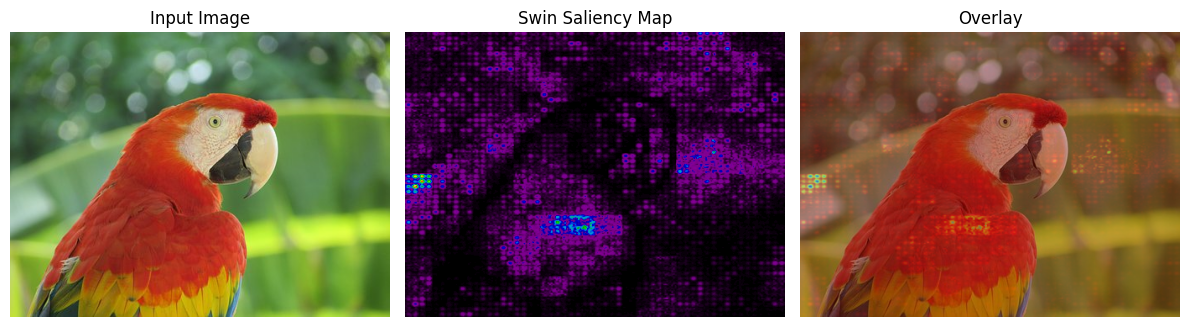

In [9]:
# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Swin Saliency Map")
plt.imshow(heatmap, cmap="nipy_spectral")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

### Few Shot Learning with CLIP

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


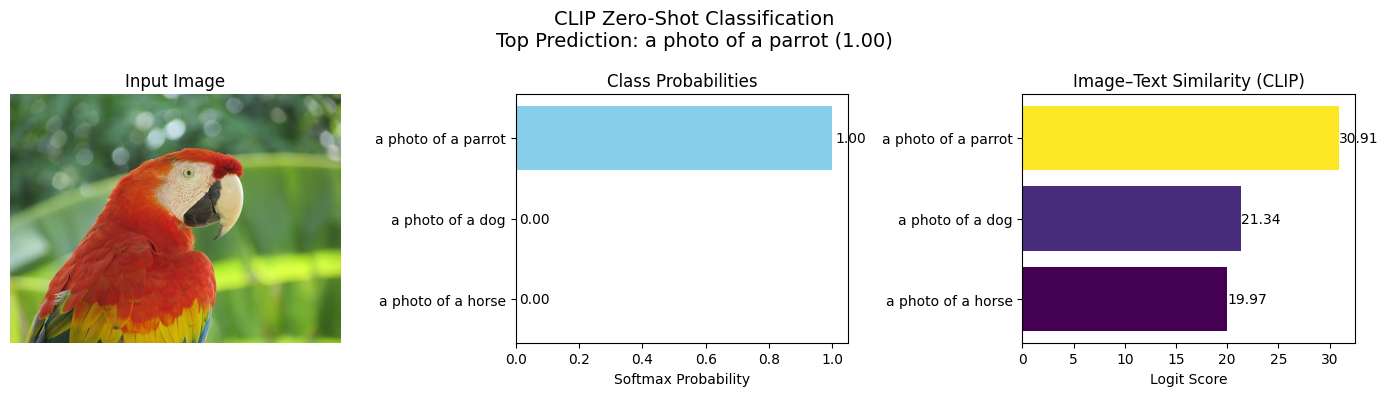

In [8]:
%matplotlib inline
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# -----------------------------
# Load CLIP
# -----------------------------
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model.eval()

# -----------------------------
# Load Image
# -----------------------------
image = Image.open("images/parrot.png").convert("RGB")

classes = ["a photo of a dog", "a photo of a horse", "a photo of a parrot"]

inputs = processor(text=classes, images=image, return_tensors="pt", padding=True)

# -----------------------------
# Hook for Grad-CAM
# -----------------------------
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# Hook LAST attention block output (better than encoder layer output)
target_layer = model.vision_model.encoder.layers[-1].layer_norm1
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# -----------------------------
# Forward
# -----------------------------
outputs = model(**inputs)
logits = outputs.logits_per_image
probs = logits.softmax(dim=1)

class_idx = torch.argmax(probs, dim=1).item()

# -----------------------------
# Backward
# -----------------------------
model.zero_grad()
logits[0, class_idx].backward()

# -----------------------------
# Get activations & gradients
# -----------------------------
acts = activations[0]   # [1, tokens, dim]
grads = gradients[0]    # same shape

# Remove CLS token
acts = acts[:, 1:, :]
grads = grads[:, 1:, :]

# -----------------------------
# Compute weights (important fix)
# -----------------------------
weights = grads.mean(dim=1)  # [1, dim]

# Weighted sum across channels
cam = (acts * weights.unsqueeze(1)).sum(dim=2)

# -----------------------------
# Reshape to spatial grid
# -----------------------------
num_tokens = cam.shape[1]
grid_size = int(num_tokens ** 0.5)

cam = cam.reshape(grid_size, grid_size).detach().cpu().numpy()

# -----------------------------
# Normalize (FIX: avoid flat map)
# -----------------------------
cam = cam - cam.min()
if cam.max() > 0:
    cam = cam / cam.max()

# -----------------------------
# Resize & overlay
# -----------------------------
img_np = np.array(image)

cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

heatmap = cv2.applyColorMap(
    np.uint8(255 * cam_resized),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

# -----------------------------
# Plot
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Prepare Data
# -----------------------------
labels = classes

# Probabilities
probs_np = probs[0].detach().cpu().numpy()

# Raw similarities (important!)
logits_np = logits[0].detach().cpu().numpy()

# Normalize similarities (for visualization only)
sim_norm = (logits_np - logits_np.min()) / (logits_np.max() - logits_np.min() + 1e-8)

# Sort by probability
sorted_idx = np.argsort(probs_np)[::-1]

labels_sorted = [labels[i] for i in sorted_idx]
probs_sorted = probs_np[sorted_idx]
logits_sorted = logits_np[sorted_idx]
sim_sorted = sim_norm[sorted_idx]

top_label = labels_sorted[0]
top_prob = probs_sorted[0]

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = np.array(axes).reshape(-1)

# ---- Image ----
axes[0].imshow(image)
axes[0].set_title("Input Image")
axes[0].axis("off")

# ---- Probability Bar ----
y_pos = np.arange(len(labels_sorted))
axes[1].barh(y_pos, probs_sorted, color="skyblue")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(labels_sorted)
axes[1].invert_yaxis()
axes[1].set_title("Class Probabilities")
axes[1].set_xlabel("Softmax Probability")

# annotate
for i, v in enumerate(probs_sorted):
    axes[1].text(v + 0.01, i, f"{v:.2f}", va='center')

# ---- Similarity Bar (CLIP core idea) ----
colors = plt.cm.viridis(sim_sorted)  # color encodes similarity

axes[2].barh(y_pos, logits_sorted, color=colors)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(labels_sorted)
axes[2].invert_yaxis()
axes[2].set_title("Image–Text Similarity (CLIP)")
axes[2].set_xlabel("Logit Score")

# annotate
for i, v in enumerate(logits_sorted):
    axes[2].text(v + 0.01, i, f"{v:.2f}", va='center')

# -----------------------------
# Global Title
# -----------------------------
plt.suptitle(
    f"CLIP Zero-Shot Classification\nTop Prediction: {top_label} ({top_prob:.2f})",
    fontsize=14
)

plt.tight_layout()
plt.show()

### with Dinov2

In [2]:
import torch
import timm
import numpy as np
from PIL import Image
import torchvision.transforms as T

# -----------------------------
# Load DINOv2 (from timm)
# -----------------------------
model = timm.create_model("vit_base_patch14_dinov2.lvd142m", pretrained=True)
model.eval()

# Remove classification head → use embeddings
model.reset_classifier(0)

# -----------------------------
# Transform
# -----------------------------
transform = T.Compose([
    T.Resize((518, 518)),  # ✅ FIX
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),  # better for pretrained models
                std=(0.229, 0.224, 0.225))
])

def get_embedding(path):
    img = Image.open(path).convert("RGB")
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        emb = model(x)
    return emb.squeeze()

# -----------------------------
# Few-shot support set
# -----------------------------
support_set = {
    "dog": ["images/dog1.png", "images/dog2.png"],
    "cat": ["images/cat1.png", "images/cat2.png"]
}

# Build prototypes
prototypes = {}
for cls, paths in support_set.items():
    embs = [get_embedding(p) for p in paths]
    prototypes[cls] = torch.stack(embs).mean(0)

# -----------------------------
# Query
# -----------------------------
query_emb = get_embedding("images/lab.png")

# Compute similarity
scores = {}
for cls, proto in prototypes.items():
    sim = torch.nn.functional.cosine_similarity(query_emb, proto, dim=0)
    scores[cls] = sim.item()

# Sort
scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))

print("Prediction:")
for k, v in scores.items():
    print(f"{k}: {v:.4f}")

Prediction:
dog: 0.1764
cat: 0.1138


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

def visualize_dinov2(query_path, support_set, prototypes, scores, top_k=2):

    # -----------------------------
    # Sort scores
    # -----------------------------
    sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_items = sorted_items[:top_k]

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(1, top_k + 1, figsize=(4*(top_k+1), 4))
    axes = np.array(axes).reshape(-1)

    # ---- Query Image ----
    axes[0].imshow(Image.open(query_path))
    axes[0].set_title("Query Image")
    axes[0].axis("off")

    # ---- Top Matches ----
    for i, (cls, score) in enumerate(top_items):
        img_path = support_set[cls][0]  # show first support image

        axes[i+1].imshow(Image.open(img_path))
        axes[i+1].set_title(f"{cls}\nSimilarity: {score:.2f}")
        axes[i+1].axis("off")

    # -----------------------------
    # Title
    # -----------------------------
    best_class, best_score = top_items[0]

    plt.suptitle(
        f"DINOv2 Few-Shot Classification\nPrediction: {best_class} ({best_score:.2f})",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

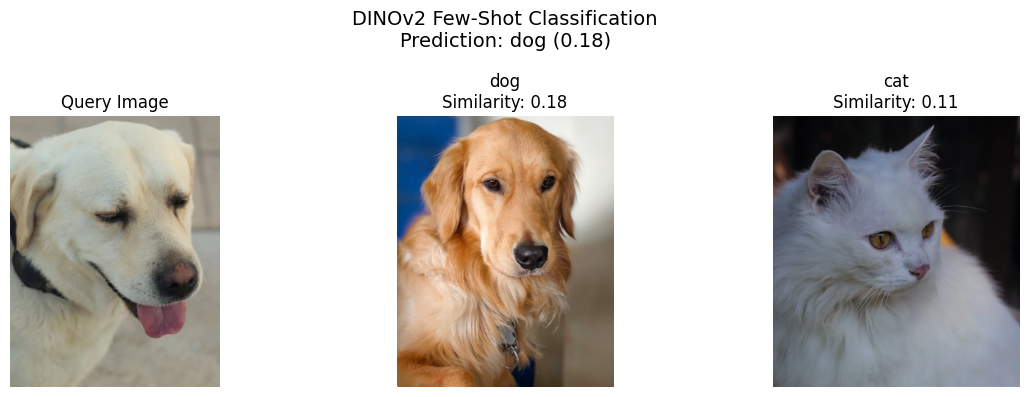

In [3]:
visualize_dinov2(
    query_path="images/lab.png",
    support_set=support_set,
    prototypes=prototypes,
    scores=scores,
    top_k=2
)

### with Siamese Network

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image

# -----------------------------
# Siamese Model
# -----------------------------
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image

# -----------------------------
# Siamese Model (FIXED)
# -----------------------------
class SiameseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # ✅ FIX
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 256),
            nn.ReLU()
        )

    def encode(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

    def forward(self, x1, x2):
        f1 = self.encode(x1)
        f2 = self.encode(x2)
        return f1, f2
        
# -----------------------------
# Distance function
# -----------------------------
def contrastive_loss(f1, f2, label, margin=1.0):
    dist = torch.norm(f1 - f2, dim=1)
    loss = label * dist**2 + (1-label) * torch.clamp(margin - dist, min=0)**2
    return loss.mean()

# -----------------------------
# Transform
# -----------------------------
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

def load_img(path):
    return transform(Image.open(path).convert("RGB")).unsqueeze(0)

# -----------------------------
# Initialize
# -----------------------------
model = SiameseNet()

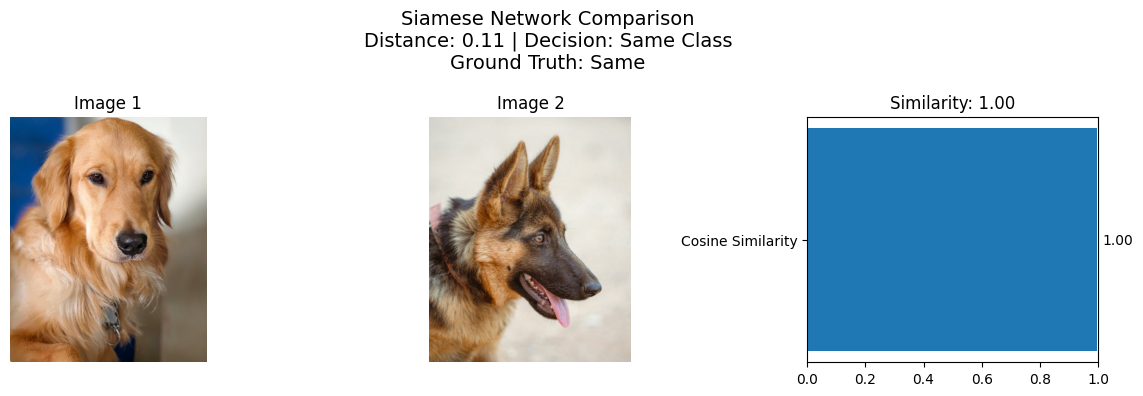

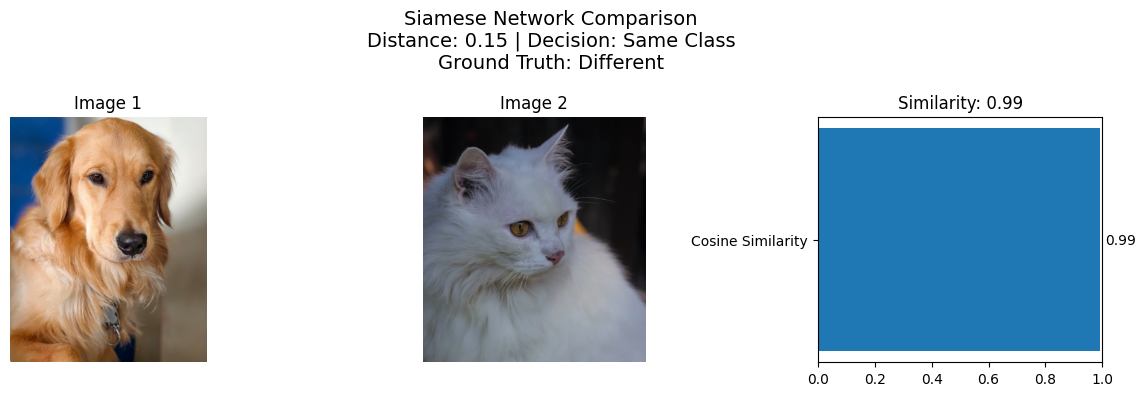

In [2]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

def visualize_siamese(img_path1, img_path2, model, label=None):

    # Load images
    img1 = load_img(img_path1)
    img2 = load_img(img_path2)

    # Forward pass
    with torch.no_grad():
        f1, f2 = model(img1, img2)

    # Distance & similarity
    dist = torch.norm(f1 - f2, dim=1).item()
    sim = F.cosine_similarity(f1, f2).item()

    # Decision
    decision = "Same Class" if sim > 0.5 else "Different Class"

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes = np.array(axes).reshape(-1)

    # ---- Image 1 ----
    axes[0].imshow(Image.open(img_path1))
    axes[0].set_title("Image 1")
    axes[0].axis("off")

    # ---- Image 2 ----
    axes[1].imshow(Image.open(img_path2))
    axes[1].set_title("Image 2")
    axes[1].axis("off")

    # ---- Similarity Bar ----
    axes[2].barh(["Cosine Similarity"], [sim])
    axes[2].set_xlim(0, 1)
    axes[2].set_title(f"Similarity: {sim:.2f}")
    
    # Annotate
    axes[2].text(sim + 0.02, 0, f"{sim:.2f}", va='center')

    # -----------------------------
    # Global Title
    # -----------------------------
    title = f"Siamese Network Comparison\nDistance: {dist:.2f} | Decision: {decision}"
    
    if label is not None:
        title += f"\nGround Truth: {'Same' if label==1 else 'Different'}"

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_siamese("images/dog1.png", "images/dog2.png", model, label=1)
visualize_siamese("images/dog1.png", "images/cat1.png", model, label=0)

### Face Recognition

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as T
from torchvision import models

# -----------------------------
# Config
# -----------------------------
gallery_dir = "images/gallery"   # structure: gallery/person_name/*.jpg
query_image = "images/galleryme.jpg" # single face image
threshold = 0.6           # cosine similarity threshold (tune)

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Transform (simple; assume faces are roughly cropped)
# -----------------------------
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
])

def load_image(path):
    return transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

# -----------------------------
# Siamese Encoder (ResNet backbone)
# -----------------------------
class FaceEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # remove classification head
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        feat = self.backbone(x)          # [B, 512]
        emb = self.projector(feat)       # [B, D]
        emb = F.normalize(emb, dim=1)    # L2-normalize
        return emb

# -----------------------------
# Build model
# -----------------------------
model = FaceEncoder(embedding_dim=128).to(device)
model.eval()

# -----------------------------
# Build gallery (embeddings per person)
# -----------------------------
def build_gallery_embeddings(root_dir):
    gallery = {}
    with torch.no_grad():
        for person in os.listdir(root_dir):
            person_dir = os.path.join(root_dir, person)
            if not os.path.isdir(person_dir):
                continue

            embs = []
            for img_name in os.listdir(person_dir):
                if not img_name.lower().endswith((".jpg",".jpeg",".png")):
                    continue
                img_path = os.path.join(person_dir, img_name)
                x = load_image(img_path)
                emb = model(x)           # [1, D]
                embs.append(emb.squeeze(0))

            if len(embs) > 0:
                # average embedding (prototype)
                gallery[person] = torch.stack(embs).mean(0)
    return gallery

gallery = build_gallery_embeddings(gallery_dir)

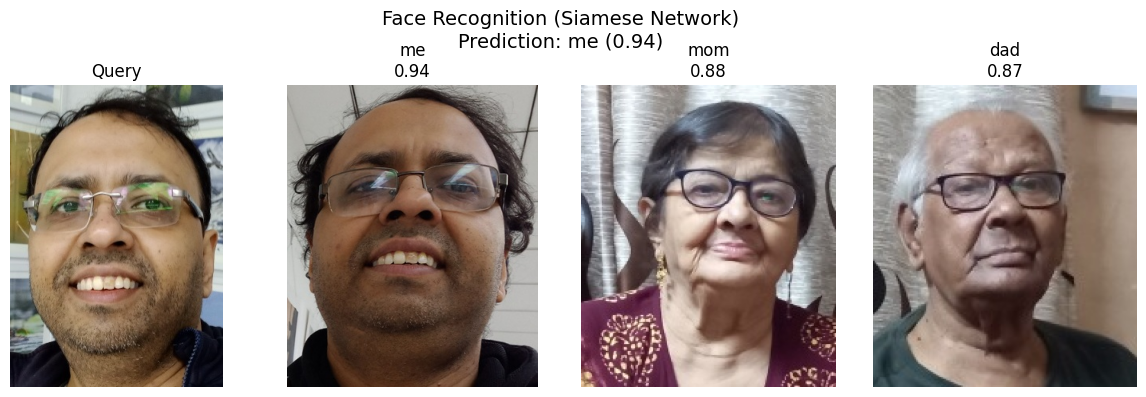

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

def visualize_recognition(query_path, gallery, model, threshold=0.6, top_k=3):

    # -----------------------------
    # Compute query embedding
    # -----------------------------
    with torch.no_grad():
        q = load_image(query_path)
        q_emb = model(q).squeeze(0)

    # -----------------------------
    # Compute similarities
    # -----------------------------
    results = []
    for person, g_emb in gallery.items():
        sim = torch.nn.functional.cosine_similarity(q_emb, g_emb, dim=0).item()
        results.append((person, sim))

    # Sort
    results = sorted(results, key=lambda x: x[1], reverse=True)
    top_results = results[:top_k]

    best_person, best_score = top_results[0]

    if best_score < threshold:
        final_label = "Unknown"
    else:
        final_label = best_person

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12, 4))

    # ---- Query Image ----
    plt.subplot(1, top_k + 1, 1)
    plt.imshow(Image.open(query_path))
    plt.title("Query")
    plt.axis("off")

    # ---- Top Matches ----
    for i, (person, score) in enumerate(top_results):

        # pick first image of that person
        person_dir = os.path.join("images", "gallery", person)
        img_name = os.listdir(person_dir)[0]
        img_path = os.path.join(person_dir, img_name)

        plt.subplot(1, top_k + 1, i + 2)
        plt.imshow(Image.open(img_path))
        plt.title(f"{person}\n{score:.2f}")
        plt.axis("off")

    # ---- Global Title ----
    plt.suptitle(
        f"Face Recognition (Siamese Network)\nPrediction: {final_label} ({best_score:.2f})",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


visualize_recognition(
    query_path="images/me.jpg",
    gallery=gallery,
    model=model,
    threshold=0.6,
    top_k=3
)

### Bayesian Neural Net for Image Classification

Epoch 0 | BNN Loss: 2.3793 | DNN Loss: 2.2328
Epoch 20 | BNN Loss: 2.0253 | DNN Loss: 0.3403
Epoch 40 | BNN Loss: 1.6386 | DNN Loss: 0.0908
Epoch 60 | BNN Loss: 1.2513 | DNN Loss: 0.0304
Epoch 80 | BNN Loss: 0.9832 | DNN Loss: 0.0841

📊 Accuracy Comparison
Deterministic NN Accuracy: 0.9694
Bayesian NN Accuracy:      0.8833


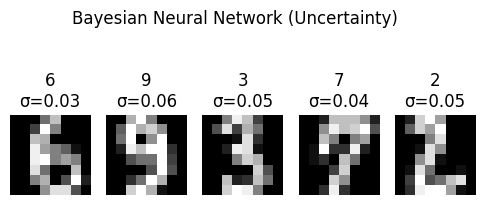

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# =============================
# Bayesian Layers
# =============================
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight_mu = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.weight_logvar = nn.Parameter(torch.full((out_features, in_features), -5.0))

        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        self.bias_logvar = nn.Parameter(torch.full((out_features,), -5.0))

    def forward(self, x):
        weight_std = torch.exp(0.5 * self.weight_logvar)
        bias_std = torch.exp(0.5 * self.bias_logvar)

        weight = self.weight_mu + weight_std * torch.randn_like(weight_std)
        bias = self.bias_mu + bias_std * torch.randn_like(bias_std)

        return F.linear(x, weight, bias)

    def kl_loss(self):
        kl = -0.5 * torch.sum(
            1 + self.weight_logvar - self.weight_mu.pow(2) - self.weight_logvar.exp()
        )
        kl += -0.5 * torch.sum(
            1 + self.bias_logvar - self.bias_mu.pow(2) - self.bias_logvar.exp()
        )
        return kl


# =============================
# Bayesian NN
# =============================
class BayesianNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = BayesianLinear(64, 32)
        self.fc2 = BayesianLinear(32, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

    def kl_loss(self):
        return self.fc1.kl_loss() + self.fc2.kl_loss()


# =============================
# Deterministic NN
# =============================
class DeterministicNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# =============================
# Dataset
# =============================
data = load_digits()
X = data.data / 16.0
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# =============================
# Initialize Models
# =============================
bnn = BayesianNN()
dnn = DeterministicNN()

opt_bnn = torch.optim.Adam(bnn.parameters(), lr=1e-4)
opt_dnn = torch.optim.Adam(dnn.parameters(), lr=1e-3)

# =============================
# Multi-sample forward (BNN)
# =============================

def forward_mc(model, x, samples=3):
    outputs = []
    for _ in range(samples):
        outputs.append(model(x))
    return torch.stack(outputs).mean(0)

# =============================
# Training
# =============================
for epoch in range(100):

    bnn.train()
    dnn.train()

    #beta = min(1.0, epoch / 50)
    beta = min(0.1, epoch / 100)
    
    for x_batch, y_batch in loader:

        # -------- BNN --------
        #out_bnn = bnn(x_batch)
        out_bnn = forward_mc(bnn, x_batch, samples=3)
        ce = F.cross_entropy(out_bnn, y_batch, reduction='mean')
        kl = bnn.kl_loss() / len(train_dataset)
        #loss_bnn = ce + beta * kl
        loss_bnn = ce + 0.01 * beta * kl
        
        opt_bnn.zero_grad()
        loss_bnn.backward()
        torch.nn.utils.clip_grad_norm_(bnn.parameters(), 5.0)
        opt_bnn.step()

        # -------- DNN --------
        out_dnn = dnn(x_batch)
        loss_dnn = F.cross_entropy(out_dnn, y_batch)

        opt_dnn.zero_grad()
        loss_dnn.backward()
        opt_dnn.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | BNN Loss: {loss_bnn:.4f} | DNN Loss: {loss_dnn:.4f}")


# =============================
# Evaluation
# =============================
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        preds = logits.argmax(dim=1)
        acc = (preds == y).float().mean()
    return acc.item()


# Deterministic Accuracy
acc_dnn = accuracy(dnn, X_test, y_test)

# Bayesian Accuracy (MC sampling)
def bnn_accuracy(model, X, y, samples=20):
    model.eval()
    preds = []

    with torch.no_grad():
        for _ in range(samples):
            logits = model(X)
            preds.append(F.softmax(logits, dim=1).unsqueeze(0))

    mean = torch.cat(preds, dim=0).mean(0)
    final_pred = mean.argmax(dim=1)
    acc = (final_pred == y).float().mean()
    return acc.item(), mean


acc_bnn, mean_probs = bnn_accuracy(bnn, X_test, y_test)

print("\n📊 Accuracy Comparison")
print(f"Deterministic NN Accuracy: {acc_dnn:.4f}")
print(f"Bayesian NN Accuracy:      {acc_bnn:.4f}")


# =============================
# Uncertainty Visualization
# =============================
def predict_mc(model, x, samples=20):
    model.eval()
    preds = []

    with torch.no_grad():
        for _ in range(samples):
            logits = model(x)
            preds.append(F.softmax(logits, dim=1).unsqueeze(0))

    preds = torch.cat(preds, dim=0)
    return preds.mean(0), preds.std(0)


mean_probs, uncertainty = predict_mc(bnn, X_test[:5])

plt.figure(figsize=(6,3))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')
    pred = mean_probs[i].argmax().item()
    unc = uncertainty[i].mean().item()
    plt.title(f"{pred}\nσ={unc:.2f}")
    plt.axis('off')

plt.suptitle("Bayesian Neural Network (Uncertainty)")
plt.show()

#### MC Dropout

Epoch 0 | MC Loss: 2.1132 | DNN Loss: 2.1770
Epoch 20 | MC Loss: 0.2304 | DNN Loss: 0.1610
Epoch 40 | MC Loss: 0.2106 | DNN Loss: 0.1636
Epoch 60 | MC Loss: 0.0586 | DNN Loss: 0.0451
Epoch 80 | MC Loss: 0.1104 | DNN Loss: 0.0734

📊 Accuracy Comparison
Deterministic NN Accuracy: 0.9722
MC Dropout Accuracy:       0.9750


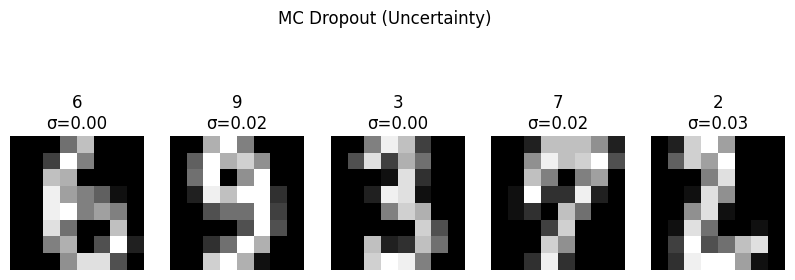

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# =============================
# MC Dropout Model
# =============================
class MCDropoutNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 64)
        self.dropout = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)   # 🔥 key layer
        x = self.fc2(x)
        return x


# =============================
# Deterministic NN
# =============================
class DeterministicNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# =============================
# Dataset
# =============================
data = load_digits()
X = data.data / 16.0
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


# =============================
# Initialize Models
# =============================
mc_model = MCDropoutNN()
dnn = DeterministicNN()

opt_mc = torch.optim.Adam(mc_model.parameters(), lr=1e-3)
opt_dnn = torch.optim.Adam(dnn.parameters(), lr=1e-3)


# =============================
# Training Loop
# =============================
for epoch in range(100):

    mc_model.train()
    dnn.train()

    for x_batch, y_batch in loader:

        # -------- MC Dropout --------
        out_mc = mc_model(x_batch)
        loss_mc = F.cross_entropy(out_mc, y_batch)

        opt_mc.zero_grad()
        loss_mc.backward()
        opt_mc.step()

        # -------- Deterministic --------
        out_dnn = dnn(x_batch)
        loss_dnn = F.cross_entropy(out_dnn, y_batch)

        opt_dnn.zero_grad()
        loss_dnn.backward()
        opt_dnn.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | MC Loss: {loss_mc:.4f} | DNN Loss: {loss_dnn:.4f}")


# =============================
# Accuracy Functions
# =============================
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


# =============================
# MC Dropout Inference
# =============================
def mc_dropout_predict(model, x, samples=20):
    model.train()  # 🔥 KEEP DROPOUT ON
    preds = []

    with torch.no_grad():
        for _ in range(samples):
            logits = model(x)
            preds.append(F.softmax(logits, dim=1).unsqueeze(0))

    preds = torch.cat(preds, dim=0)
    return preds.mean(0), preds.std(0)


# =============================
# Evaluation
# =============================
acc_dnn = accuracy(dnn, X_test, y_test)

mean_probs, uncertainty = mc_dropout_predict(mc_model, X_test)
preds_mc = mean_probs.argmax(dim=1)
acc_mc = (preds_mc == y_test).float().mean().item()

print("\n📊 Accuracy Comparison")
print(f"Deterministic NN Accuracy: {acc_dnn:.4f}")
print(f"MC Dropout Accuracy:       {acc_mc:.4f}")


# =============================
# Visualization
# =============================
mean_probs, uncertainty = mc_dropout_predict(mc_model, X_test[:5])

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')

    pred = mean_probs[i].argmax().item()
    unc = uncertainty[i].mean().item()

    plt.title(f"{pred}\nσ={unc:.2f}")
    plt.axis('off')

plt.suptitle("MC Dropout (Uncertainty)")
plt.show()

## Semisupervised Classification

Epoch 0, Sup Loss: 3.1027, Unsup Loss: 0.2330, Used: 271/1294
Epoch 20, Sup Loss: 0.5015, Unsup Loss: 0.1173, Used: 584/1294
Epoch 40, Sup Loss: 0.0783, Unsup Loss: 0.0575, Used: 1096/1294
Epoch 60, Sup Loss: 0.0237, Unsup Loss: 0.0333, Used: 1166/1294
Epoch 80, Sup Loss: 0.0118, Unsup Loss: 0.0240, Used: 1202/1294
Epoch 100, Sup Loss: 0.0074, Unsup Loss: 0.0196, Used: 1225/1294
Epoch 120, Sup Loss: 0.0053, Unsup Loss: 0.0162, Used: 1244/1294
Epoch 140, Sup Loss: 0.0035, Unsup Loss: 0.0122, Used: 1247/1294
Epoch 160, Sup Loss: 0.0026, Unsup Loss: 0.0100, Used: 1250/1294
Epoch 180, Sup Loss: 0.0022, Unsup Loss: 0.0098, Used: 1260/1294

📊 Results
Supervised Only Accuracy: 0.8944
Semi-Supervised Accuracy:  0.9278


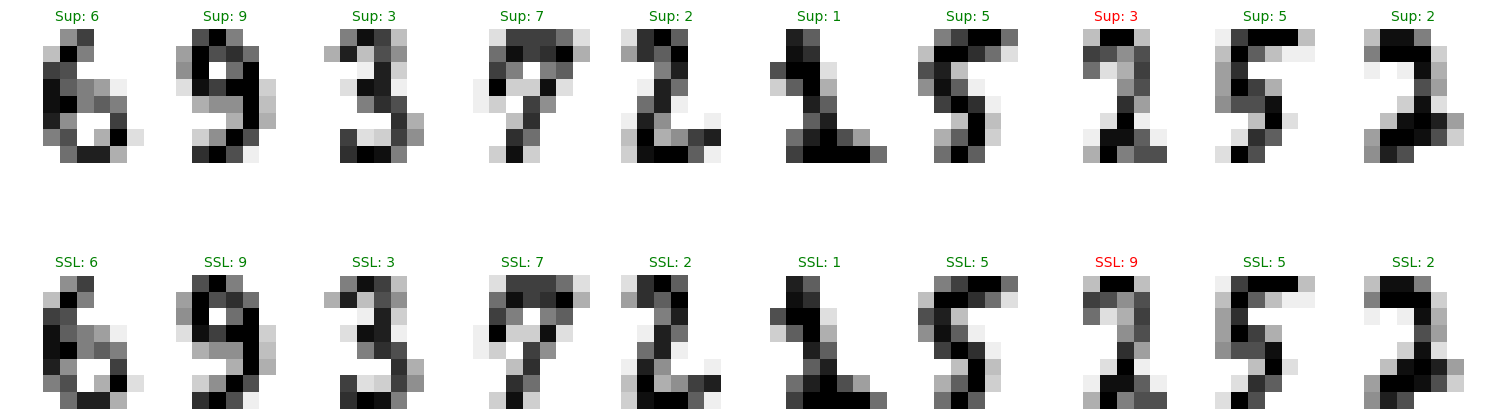

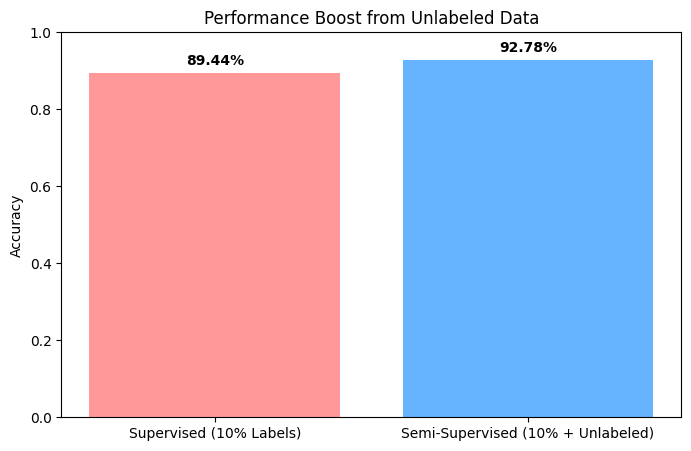

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# =============================
# Dataset
# =============================
data = load_digits()
# Remove the /16.0 or use standard scaling for better gradients in small nets
X = data.data #/ 16.0 
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 10% labeled
num_labeled = int(0.1 * len(X_train))

X_l = torch.tensor(X_train[:num_labeled], dtype=torch.float32)
y_l = torch.tensor(y_train[:num_labeled], dtype=torch.long)
X_u = torch.tensor(X_train[num_labeled:], dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# =============================
# Model
# =============================
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 128) # Slightly wider for better capacity
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

model_ssl = Net()
model_sup = Net()

opt_ssl = torch.optim.Adam(model_ssl.parameters(), lr=1e-3)
opt_sup = torch.optim.Adam(model_sup.parameters(), lr=1e-3)

# =============================
# Fully Supervised
# =============================
for epoch in range(100):
    logits = model_sup(X_l)
    loss = F.cross_entropy(logits, y_l)
    opt_sup.zero_grad()
    loss.backward()
    opt_sup.step()

# =============================
# SSL Training (FixMatch-lite)
# =============================
tau = 0.7  # Constant threshold works better for this simple dataset
lambda_u = 1.0

for epoch in range(200):
    # ---- Supervised Loss ----
    logits_l = model_ssl(X_l)
    loss_sup = F.cross_entropy(logits_l, y_l)

    # ---- Unsupervised Loss (Consistency) ----
    # 1. Weak augmentation (Original)
    with torch.no_grad():
        weak_logits = model_ssl(X_u)
        probs = F.softmax(weak_logits, dim=1)
        max_probs, pseudo_labels = probs.max(dim=1)
        mask = max_probs >= tau

    # 2. Strong augmentation (Add Gaussian Noise)
    # This is CRITICAL for SSL; otherwise, strong == weak
    noise = torch.randn_like(X_u) * 0.05 
    strong_logits = model_ssl(X_u + noise)

    if mask.sum() > 0:
        loss_unsup = F.cross_entropy(strong_logits[mask], pseudo_labels[mask])
        loss = loss_sup + lambda_u * loss_unsup
        used = mask.sum().item()
    else:
        loss_unsup = torch.tensor(0.0)
        loss = loss_sup
        used = 0

    opt_ssl.zero_grad()
    loss.backward()
    opt_ssl.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Sup Loss: {loss_sup:.4f}, Unsup Loss: {loss_unsup:.4f}, Used: {used}/{len(X_u)}")

# =============================
# Accuracy & Visualization
# =============================
def get_acc(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
        return (preds == y).float().mean().item()

print("\n📊 Results")
print(f"Supervised Only Accuracy: {get_acc(model_sup, X_test_t, y_test_t):.4f}")
print(f"Semi-Supervised Accuracy:  {get_acc(model_ssl, X_test_t, y_test_t):.4f}")

import matplotlib.pyplot as plt
import numpy as np

# Set models to evaluation mode
model_sup.eval()
model_ssl.eval()

# =============================
# Visual Prediction Grid
# =============================
plt.figure(figsize=(15, 6))
num_samples = 10

with torch.no_grad():
    # Get predictions for the first 10 test samples
    logits_sup = model_sup(X_test_t[:num_samples])
    logits_ssl = model_ssl(X_test_t[:num_samples])
    
    preds_sup = logits_sup.argmax(dim=1)
    preds_ssl = logits_ssl.argmax(dim=1)
    true_labels = y_test_t[:num_samples]

for i in range(num_samples):
    # Prepare the image (8x8 digits)
    img = X_test[i].reshape(8, 8)
    
    # --- Top Row: Supervised Only ---
    plt.subplot(2, num_samples, i + 1)
    plt.imshow(img, cmap='gray_r')
    color = 'green' if preds_sup[i] == true_labels[i] else 'red'
    plt.title(f"Sup: {preds_sup[i].item()}", color=color, fontsize=10)
    plt.axis('off')
    if i == 0: plt.ylabel("Supervised", labelpad=20, size=12)

    # --- Bottom Row: Semi-Supervised ---
    plt.subplot(2, num_samples, num_samples + i + 1)
    plt.imshow(img, cmap='gray_r')
    color = 'green' if preds_ssl[i] == true_labels[i] else 'red'
    plt.title(f"SSL: {preds_ssl[i].item()}", color=color, fontsize=10)
    plt.axis('off')
    if i == 0: plt.ylabel("Semi-Sup", labelpad=20, size=12)

plt.tight_layout()
plt.show()

# =============================
# Accuracy Comparison Bar Chart
# =============================
labels = ['Supervised (10% Labels)', 'Semi-Supervised (10% + Unlabeled)']
accuracies = [get_acc(model_sup, X_test_t, y_test_t), get_acc(model_ssl, X_test_t, y_test_t)]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, color=['#ff9999', '#66b3ff'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Performance Boost from Unlabeled Data')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center', fontweight='bold')

plt.show()

### Image Classification with Reinforcement Learning

Epoch 0 | Loss: -0.0561 | Train Acc: 0.0981 | Entropy: 1.808
Epoch 20 | Loss: -0.2600 | Train Acc: 0.9130 | Entropy: 0.136
Epoch 40 | Loss: -0.3408 | Train Acc: 0.9596 | Entropy: 0.068
Epoch 60 | Loss: -0.2015 | Train Acc: 0.9784 | Entropy: 0.037
Epoch 80 | Loss: -0.1672 | Train Acc: 0.9805 | Entropy: 0.029
Epoch 100 | Loss: -0.1961 | Train Acc: 0.9840 | Entropy: 0.021
Epoch 120 | Loss: -0.1042 | Train Acc: 0.9910 | Entropy: 0.018
Epoch 140 | Loss: -0.0149 | Train Acc: 0.9937 | Entropy: 0.007
Epoch 160 | Loss: -0.0253 | Train Acc: 0.9910 | Entropy: 0.013
Epoch 180 | Loss: -0.0552 | Train Acc: 0.9910 | Entropy: 0.013
Epoch 200 | Loss: -0.0720 | Train Acc: 0.9910 | Entropy: 0.012
Epoch 220 | Loss: -0.0469 | Train Acc: 0.9903 | Entropy: 0.009
Epoch 240 | Loss: -0.0944 | Train Acc: 0.9903 | Entropy: 0.010
Epoch 260 | Loss: -0.0328 | Train Acc: 0.9923 | Entropy: 0.004
Epoch 280 | Loss: -0.0608 | Train Acc: 0.9868 | Entropy: 0.011

🚀 Stabilized RL Accuracy: 0.9750


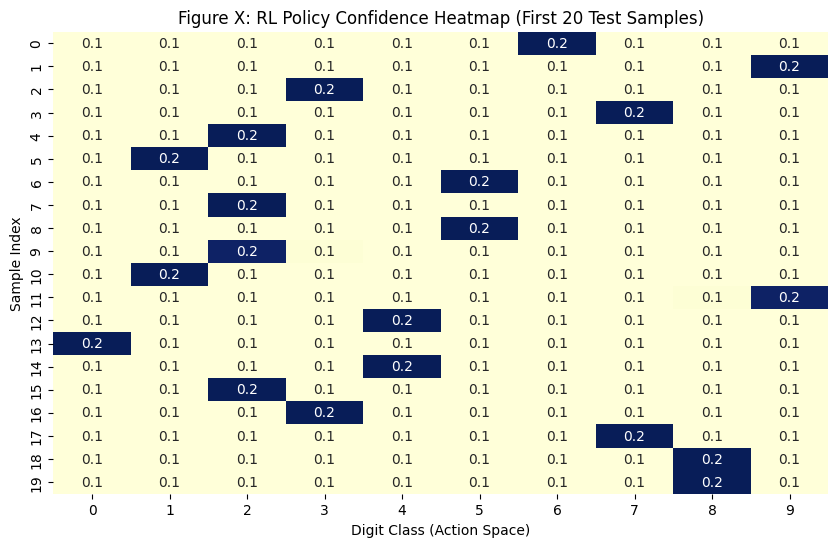

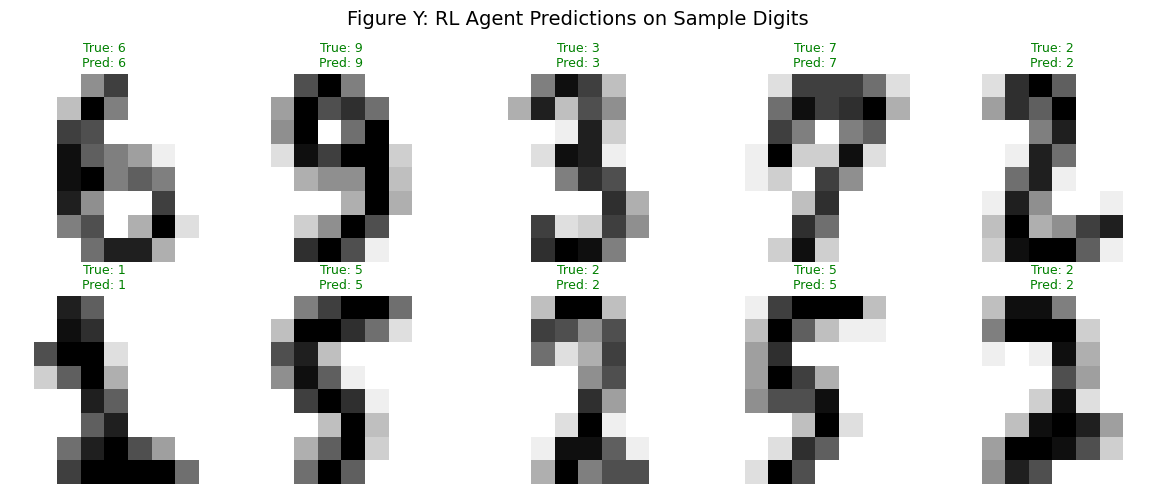

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        # We use Log-Softmax for better numerical stability with log_prob
        return F.softmax(self.fc2(x), dim=1)

model = PolicyNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

for epoch in range(300):
    model.train()
    probs = model(X_train)
    dist = torch.distributions.Categorical(probs)
    
    # 1. Sample actions (Exploration)
    actions = dist.sample()

    # 2. Rewards: +1 for correct, -0.1 for wrong 
    # (High negative rewards can actually destabilize small datasets)
    rewards = (actions == y_train).float()
    rewards = torch.where(rewards > 0, 1.0, -0.1)

    # 3. Advantage Normalization (The "Secret Sauce")
    # This standardizes the signal across the batch
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

    # 4. Policy Gradient Loss
    log_probs = dist.log_prob(actions)
    
    # We add a stronger Entropy bonus to prevent the 44% collapse
    entropy = dist.entropy().mean()
    policy_loss = -(log_probs * advantages).mean()
    loss = policy_loss - 0.05 * entropy

    optimizer.zero_grad()
    loss.backward()
    # Gradient clipping to prevent the model from "jumping" off a cliff
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if epoch % 20 == 0:
        train_acc = (actions == y_train).float().mean().item()
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Entropy: {entropy:.3f}")

# Final Evaluation
model.eval()
with torch.no_grad():
    test_probs = model(X_test)
    preds = test_probs.argmax(dim=1)
    acc = (preds == y_test).float().mean()

print(f"\n🚀 Stabilized RL Accuracy: {acc.item():.4f}")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming you tracked metrics during training in lists: 
# history_acc, history_loss, history_entropy

def visualize_rl_results(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        probs = F.softmax(logits, dim=1).numpy()
        preds = np.argmax(probs, axis=1)

    # --- 1. Confidence Heatmap (Policy Analysis) ---
    plt.figure(figsize=(10, 6))
    # Taking the first 20 samples of the test set
    sns.heatmap(probs[:20], annot=True, fmt=".1f", cmap="YlGnBu", cbar=False)
    plt.title("Figure X: RL Policy Confidence Heatmap (First 20 Test Samples)")
    plt.xlabel("Digit Class (Action Space)")
    plt.ylabel("Sample Index")
    
    # --- 2. Correct vs. Incorrect Policy Visualization ---
    plt.figure(figsize=(12, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        img = X_test[i].reshape(8, 8).numpy()
        plt.imshow(img, cmap='gray_r')
        
        color = 'green' if preds[i] == y_test[i] else 'red'
        plt.title(f"True: {y_test[i]}\nPred: {preds[i]}", color=color, fontsize=9)
        plt.axis('off')
    
    plt.suptitle("Figure Y: RL Agent Predictions on Sample Digits", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_rl_results(model, X_test, y_test)

### Adversarial Attacks on neural nets for image classification

Original class: giant_panda


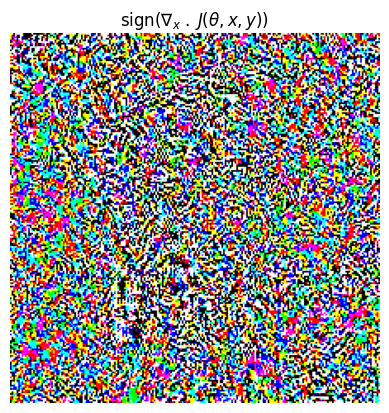

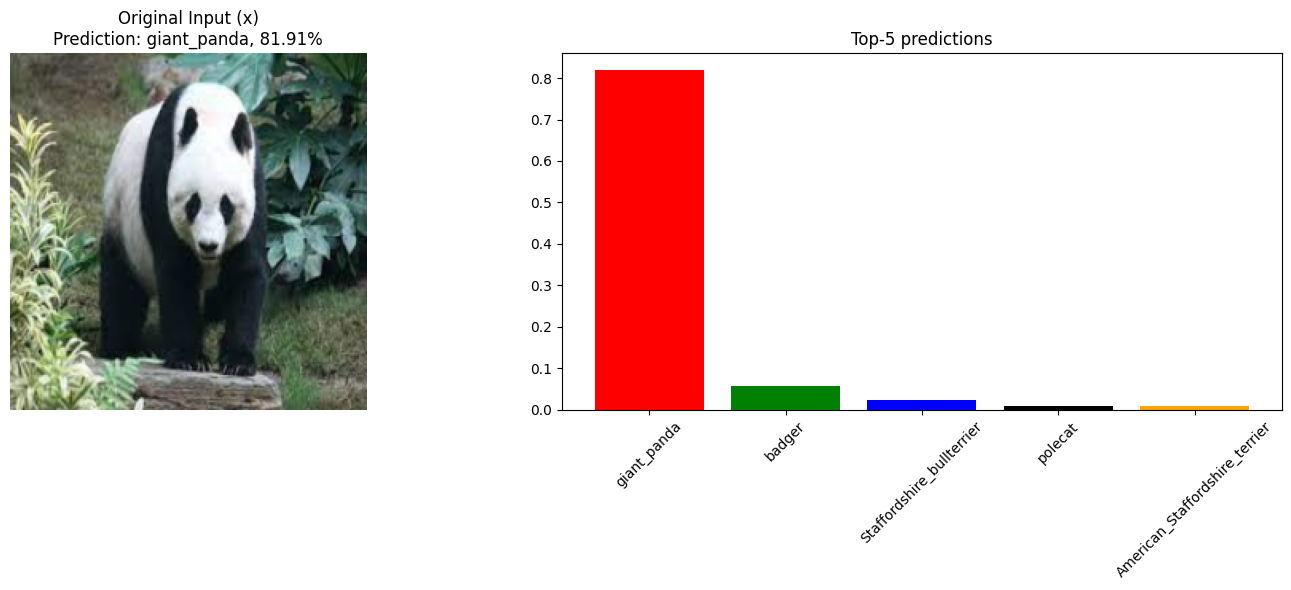

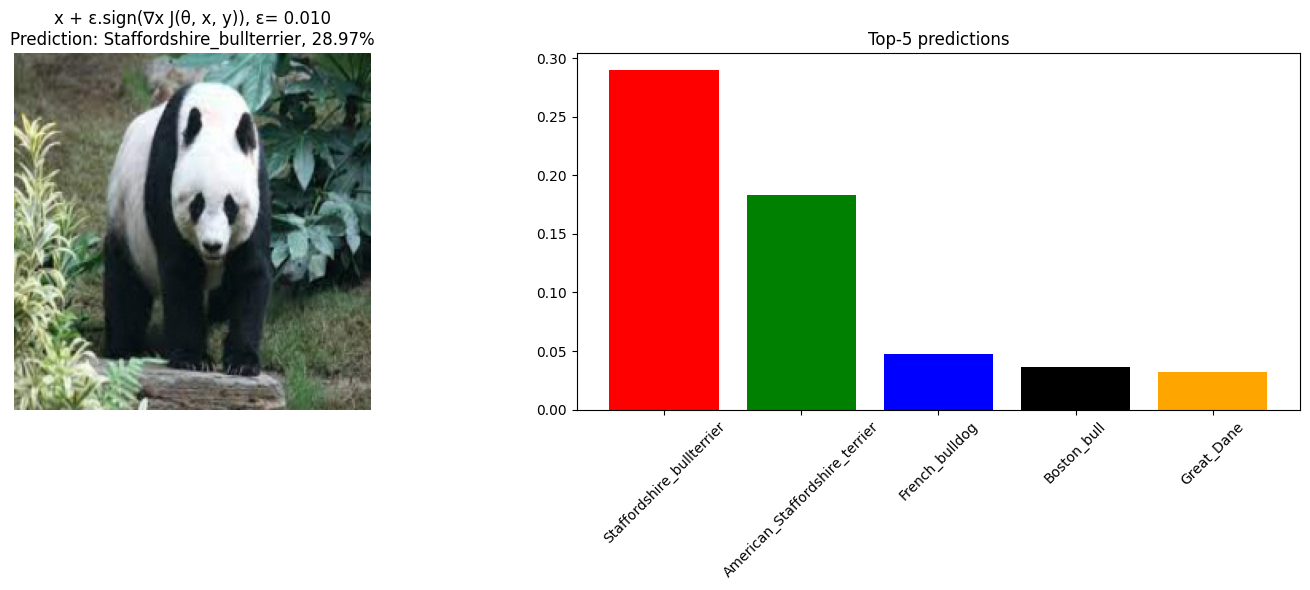

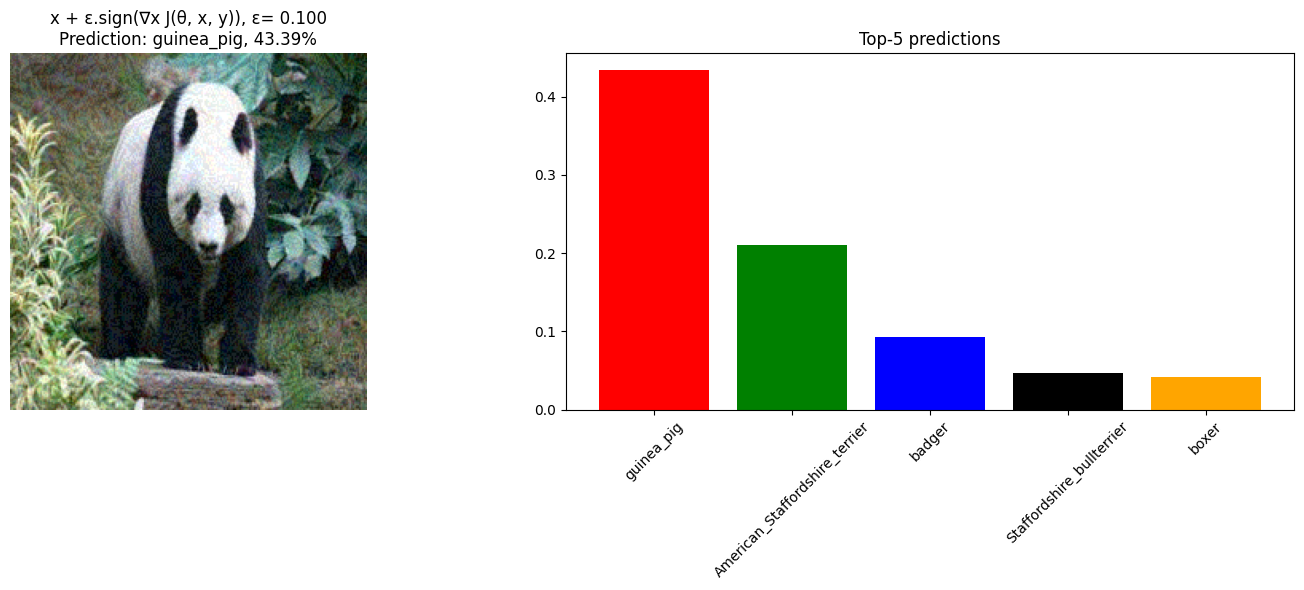

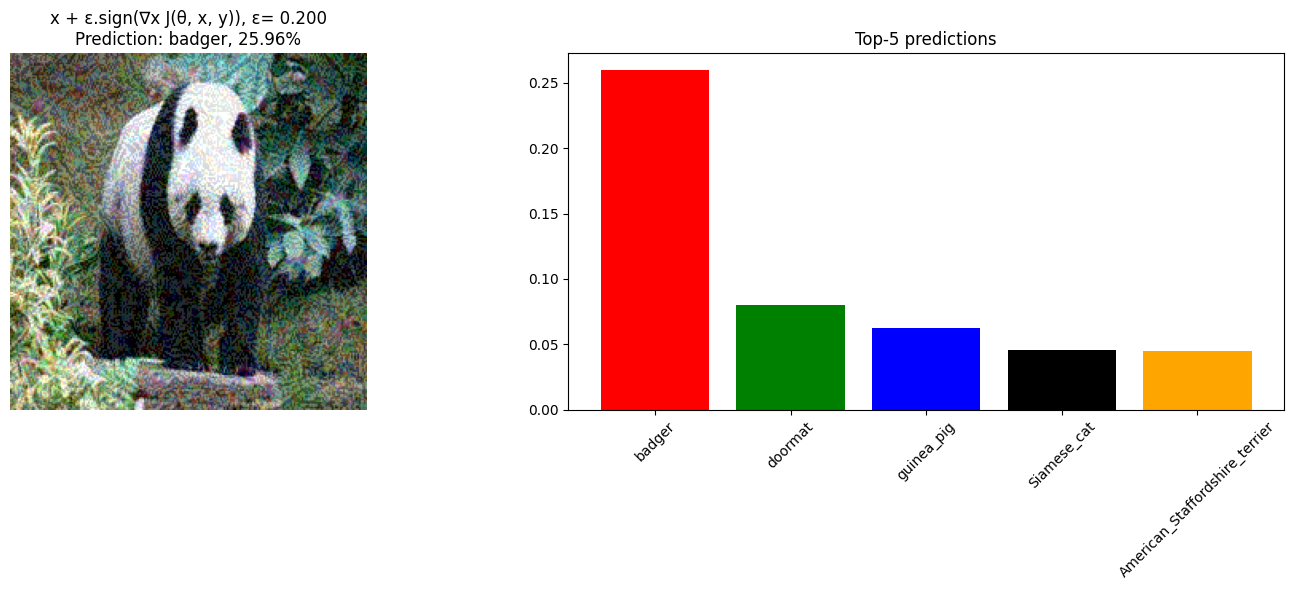

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import json, urllib.request

# Load model
model = models.mobilenet_v2(pretrained=True)
model.eval()

# TF-style preprocessing (-1 to 1)
def preprocess(img):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),   # [0,1]
    ])
    img = transform(img)
    img = img * 2 - 1           # [-1,1]  ✅ matches TF
    return img.unsqueeze(0)

# Load image
image = Image.open("images/panda.jpg").convert("RGB")
input_tensor = preprocess(image)

# Load labels
LABELS_URL = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
class_idx = json.load(urllib.request.urlopen(LABELS_URL))

def decode_predictions(output, topk=5):
    probs = torch.nn.functional.softmax(output, dim=1)
    top_probs, top_idxs = probs.topk(topk)

    results = []
    for i in range(topk):
        idx = top_idxs[0][i].item()
        label = class_idx[str(idx)][1]
        prob = top_probs[0][i].item()
        results.append((label, prob))
    return results

# Visualization (with colors)
def show_image(img_tensor, description):
    img = img_tensor.squeeze().detach().numpy()
    img = (img + 1) / 2   # back to [0,1]

    output = model(img_tensor)
    preds = decode_predictions(output)

    colors = ['red', 'green', 'blue', 'black', 'orange']

    plt.figure(figsize=(15,6))

    plt.subplot(1,2,1)
    plt.imshow(np.transpose(img, (1,2,0)))
    plt.axis('off')
    plt.title(f"{description}\nPrediction: {preds[0][0]}, {preds[0][1]*100:.2f}%")

    plt.subplot(1,2,2)
    labels = [p[0] for p in preds]
    probs = [p[1] for p in preds]
    plt.bar(labels, probs, color=colors)
    plt.xticks(rotation=45)
    plt.title("Top-5 predictions")

    plt.tight_layout()
    plt.show()

# FGSM gradient
def get_signed_grad(image, label):
    image.requires_grad = True

    output = model(image)
    loss = nn.CrossEntropyLoss()(output, label)

    model.zero_grad()
    loss.backward()

    return image.grad.sign()

# Get label
with torch.no_grad():
    output = model(input_tensor)
    class_index = torch.argmax(output, dim=1)

print("Original class:", class_idx[str(class_index.item())][1])

# Compute perturbation
perturbations = get_signed_grad(input_tensor.clone(), class_index)

# Show perturbation
plt.imshow((perturbations.squeeze().numpy().transpose(1,2,0) + 1)/2)
plt.title(r"sign$(\nabla_x\;.\;J(\theta, x, y))$")
plt.axis('off')
plt.show()

# FGSM attack
epsilons = [0, 0.01, 0.1, 0.2]
descriptions = [('x + ε.sign(∇x J(θ, x, y)), ε= {:0.3f}'.format(eps) if eps else 'Original Input (x)') for eps in epsilons]

for i, eps in enumerate(epsilons):
    adv_x = input_tensor + eps * perturbations

    # ✅ correct clamp
    adv_x = torch.clamp(adv_x, -1, 1)

    show_image(adv_x,  descriptions[i])

## **Part II: Object Detection**

---

### **with RetinaNet**

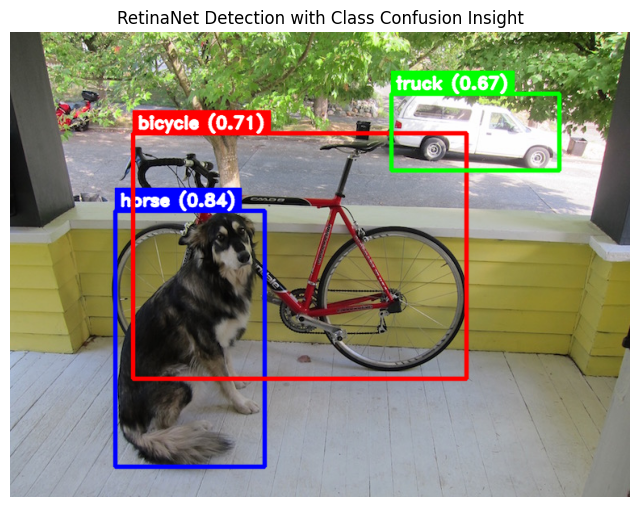

In [5]:
import torch
import torchvision
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# -----------------------------
# Load RetinaNet
# -----------------------------
model = torchvision.models.detection.retinanet_resnet50_fpn(weights="DEFAULT")
model.eval()

# -----------------------------
# COCO Classes
# -----------------------------
COCO_CLASSES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis",
    "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed",
    "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster",
    "sink", "refrigerator", "book", "clock", "vase", "scissors",
    "teddy bear", "hair drier", "toothbrush"
]

# -----------------------------
# Vibrant Colors (HSV)
# -----------------------------
def generate_colors(n):
    colors = []
    for i in range(n):
        hue = int(180 * i / n)
        hsv = np.uint8([[[hue, 255, 255]]])
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0][0]
        colors.append(rgb.tolist())
    return colors

# -----------------------------
# Load Image
# -----------------------------
image_path = "images/dog_cycle.jpg"
image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(image)

# -----------------------------
# Inference
# -----------------------------
with torch.no_grad():
    outputs = model([img_tensor])[0]

boxes = outputs["boxes"]
scores = outputs["scores"]
labels = outputs["labels"]

# -----------------------------
# Filter detections
# -----------------------------
threshold = 0.6
keep = scores >= threshold

boxes = boxes[keep]
scores = scores[keep]
labels = labels[keep]

# -----------------------------
# Assign colors per detected class
# -----------------------------
unique_labels = sorted(set(labels.cpu().numpy().tolist()))
colors = generate_colors(len(unique_labels))
COLOR_MAP = {cls: color for cls, color in zip(unique_labels, colors)}

# -----------------------------
# Visualization
# -----------------------------
img = np.array(image).copy()

for box, score, label in zip(boxes, scores, labels):

    label_id = int(label) # 🔑 FIX

    x1, y1, x2, y2 = map(int, box.tolist())
    class_name = COCO_CLASSES[label_id]
    color = COLOR_MAP[label_id]

    # Draw box
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3, lineType=cv2.LINE_AA)

    text = f"{class_name} ({score:.2f})"

    font = cv2.FONT_HERSHEY_DUPLEX
    font_scale = 0.7
    thickness = 2
    pad = 6

    (w, h), _ = cv2.getTextSize(text, font, font_scale, thickness)

    cv2.rectangle(img,
                  (x1, y1 - h - 2*pad),
                  (x1 + w + 2*pad, y1),
                  color, -1, lineType=cv2.LINE_AA)

    cv2.putText(img, text,
                (x1 + pad, y1 - pad),
                font, font_scale,
                (255, 255, 255),
                thickness,
                lineType=cv2.LINE_AA)

# -----------------------------
# Show Result
# -----------------------------
plt.figure(figsize=(8, 8))
plt.imshow(img.astype(np.uint8))
plt.title("RetinaNet Detection with Class Confusion Insight")
plt.axis("off")
plt.show()

### **with Mask R-CNN**

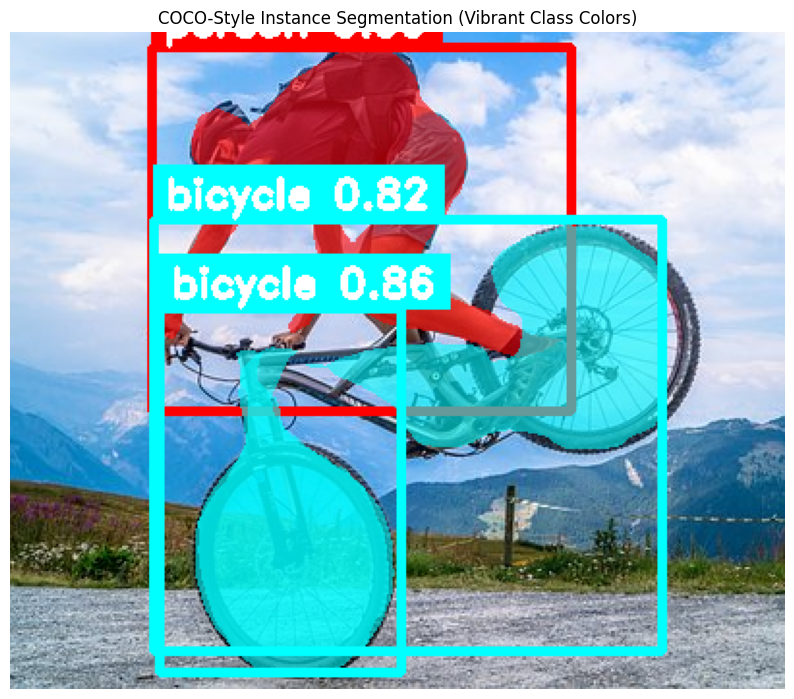

In [22]:
import torch
import torchvision
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# -----------------------------
# Load Mask R-CNN model
# -----------------------------
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
model.eval()

# -----------------------------
# COCO class labels
# -----------------------------
COCO_CLASSES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis",
    "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed",
    "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster",
    "sink", "refrigerator", "book", "clock", "vase", "scissors",
    "teddy bear", "hair drier", "toothbrush"
]

# -----------------------------
# Generate vibrant colors (HSV)
# -----------------------------
def generate_vibrant_colors(n):
    colors = []
    for i in range(n):
        hue = int(180 * i / n)
        hsv = np.uint8([[[hue, 255, 255]]])
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0][0]
        colors.append(rgb.tolist())
    return colors

# -----------------------------
# Load image
# -----------------------------
image_path = "images/cycle.jpg"  # change this
image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(image)

# -----------------------------
# Inference
# -----------------------------
with torch.no_grad():
    outputs = model([img_tensor])[0]

boxes = outputs["boxes"].cpu().numpy()
scores = outputs["scores"].cpu().numpy()
labels = outputs["labels"].cpu().numpy()
masks = outputs["masks"].cpu().numpy()

# -----------------------------
# Filter detections
# -----------------------------
threshold = 0.5
keep = scores >= threshold

boxes = boxes[keep]
scores = scores[keep]
labels = labels[keep]
masks = masks[keep]

# -----------------------------
# Assign colors ONLY to detected classes
# -----------------------------
unique_labels = sorted(set(labels.tolist()))
colors = generate_vibrant_colors(len(unique_labels))
COLOR_MAP = {cls: color for cls, color in zip(unique_labels, colors)}

# -----------------------------
# Visualization
# -----------------------------
img = np.array(image).copy()

for box, score, label, mask in zip(boxes, scores, labels, masks):

    x1, y1, x2, y2 = map(int, box)
    class_name = COCO_CLASSES[label]
    color = COLOR_MAP[label]

    # ---- Mask ----
    mask = (mask[0] > 0.6).astype(np.uint8)
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

    colored_mask = np.zeros_like(img)
    colored_mask[:] = color

    alpha = 0.6
    img = np.where(mask[:, :, None],
                   img * (1 - alpha) + colored_mask * alpha,
                   img)

    # ---- Bounding Box ----
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3, lineType=cv2.LINE_AA)

    # ---- Label ----
    text = f"{class_name} {score:.2f}"

    font = cv2.FONT_HERSHEY_DUPLEX
    font_scale = 0.7
    thickness = 2
    pad = 6

    (w, h), _ = cv2.getTextSize(text, font, font_scale, thickness)

    # Background box
    cv2.rectangle(
        img,
        (x1, y1 - h - 2 * pad),
        (x1 + w + 2 * pad, y1),
        color,
        -1,
        lineType=cv2.LINE_AA
    )

    # Text
    cv2.putText(
        img,
        text,
        (x1 + pad, y1 - pad),
        font,
        font_scale,
        (255, 255, 255),
        thickness,
        lineType=cv2.LINE_AA
    )

# -----------------------------
# Display
# -----------------------------
plt.figure(figsize=(10, 10))
plt.imshow(img.astype(np.uint8))
plt.title("COCO-Style Instance Segmentation (Vibrant Class Colors)")
plt.axis("off")
plt.show()

### OCR

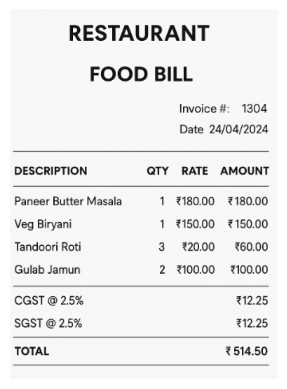

RESTAURANT
FOOD BILL

Invoice #: 1304
Date 24/04/2024

DESCRIPTION QTY RATE AMOUNT
Paneer Butter Masala 1 %180,00 2180.00
Veg Biryani 1 %150.00 150.00
Tandoori Roti 3 220,00 260.00
Gulab Jamun 2 100.00 7100.00
CGST @ 2.5% 212.25
SGST @ 2.5% 212.25

TOTAL 7514.50




In [28]:
import cv2
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

bill = cv2.imread('images/bill.png')
# Convert to grayscale
gray = cv2.cvtColor(bill, cv2.COLOR_BGR2GRAY)

# OCR
text = pytesseract.image_to_string(gray, config=r'--oem 3 --psm 4')
plt.imshow(gray, cmap='gray'), plt.axis('off'); plt.show()
print(text)

### Automatic License Plate Recognition (ALPR)

#### Fine-Tuning with Yolo-V5 and Tesseract

In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
%pip install -qr requirements.txt
%cd ..

In [47]:
# download and extract the training images from here: https://www.kaggle.com/datasets/andrewmvd/car-plate-detection into images/licenseplate
# the dataset has 433 images

In [3]:
import os, sys
import xml.etree.ElementTree as ET 
from sklearn.model_selection import train_test_split
import yaml
from yolov5 import utils
!pip install -q wandb --upgrade
import wandb
import pandas as pd
import glob

def xml_to_dataframe(xml_folder):
    rows = []

    for xml_file in glob.glob(xml_folder):
        
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        size = root.find("size")
        img_w = int(size.find("width").text)
        img_h = int(size.find("height").text)

        filename = root.find("filename").text

        for obj in root.findall("object"):
            label = obj.find("name").text
            bbox = obj.find("bndbox")
            xmin = int(bbox.find("xmin").text)
            ymin = int(bbox.find("ymin").text)
            xmax = int(bbox.find("xmax").text)
            ymax = int(bbox.find("ymax").text)
        
            # convert to YOLO format
            x_center = (xmin + xmax) / 2 / img_w
            y_center = (ymin + ymax) / 2 / img_h
            width = (xmax - xmin) / img_w
            height = (ymax - ymin) / img_h

            def clamp(val):
                return max(0, min(1, val))
            
            x_center = clamp(x_center)
            y_center = clamp(y_center)
            width = clamp(width)
            height = clamp(height)

            rows.append([
                filename, label,
                xmin, ymin, xmax, ymax,
                x_center, y_center, width, height
            ])

    columns = [
        "file", "label",
        "xmin", "ymin", "xmax", "ymax",
        "Xcent", "Ycent", "boxW", "boxH"
    ]

    return pd.DataFrame(rows, columns=columns)

sys.path.append('yolov5')
display = utils.notebook_init()

# create api key here: https://wandb.ai/
wandb.login(anonymous='must')

df = xml_to_dataframe('images/license-plate/labels/*.xml')
print(df.head())

imgs = os.listdir('images/license-plate/images')
imgs_train, imgs_val = train_test_split(imgs, test_size=0.05)

data = dict(
    train =  'yolov5/train.txt',
    val   =  'yolov5/val.txt',
    nc    = 1,
    names = ['licence'],
)

with open('yolov5/bgr.yaml', 'w') as outfile:
    yaml.dump(data, outfile, default_flow_style=False)
with open('yolov5/train.txt', 'w') as f:
    for path in imgs_train:
        f.write(cwd+'images/'+path+'\n')
with open('yolov5/val.txt', 'w') as f:
    for path in imgs_val:
        f.write(cwd+'images/'+path+'\n')
        
for file in imgs:
    #print(file)
    filename = file.split('.')[0]
    bboxs = []
    for _,row in df[df['file'] == file].iterrows():
        bbox = [str(0), str(row['Xcent']), str(row['Ycent']), str(row['boxW']), str(row['boxH'])]
        bbox = ' '.join(bbox)
        bboxs.append(bbox)
    with open('../images/license-plate/labels/'+filename+'.txt', 'w') as f:
        bboxs = '\n'.join(bboxs)
        f.write(bboxs)

YOLOv5  2026-4-25 Python-3.14.0 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)


Setup complete  (8 CPUs, 23.7 GB RAM, 1845.8/1863.0 GB disk)
          file    label  xmin  ymin  xmax  ymax    Xcent     Ycent    boxW  \
0    Cars0.png  licence   226   125   419   173  0.64500  0.555970  0.3860   
1    Cars1.png  licence   134   128   262   160  0.49500  0.580645  0.3200   
2   Cars10.png  licence   140     5   303   148  0.55375  0.340000  0.4075   
3  Cars100.png  licence   175   114   214   131  0.48625  0.458801  0.0975   
4  Cars101.png  licence   167   202   240   220  0.50875  0.703333  0.1825   

       boxH  
0  0.179104  
1  0.129032  
2  0.635556  
3  0.063670  
4  0.060000  


In [ ]:
%cd yolov5

In [ ]:
!python train.py --img 1280 --batch 4 --epochs 20 --data bgr.yaml --weights ../models/yolov5m6.pt --device 0

In [ ]:
!python detect.py --source ../images/car.png --weights ../models/yolov5m6.pt

In [41]:
%matplotlib inline
import torch
from PIL import Image
import numpy as np
import matplotlib.pylab as plt

CKPT_PATH = '../models/yolov5m6.pt' #'runs/train/exp11/weights/best.pt'
yolov5 = torch.hub.load('.',
                        'custom',
                        path=CKPT_PATH,
                        source='local',
                        force_reload=True)

img = Image.open('../images/car.png').convert('RGB')
img = np.asarray(img)
pred = yolov5(img, size=1280, augment=False)
pred.pandas().xyxy[0]

YOLOv5  2026-4-25 Python-3.14.0 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)

Fusing layers... 
Model summary: 378 layers, 35248920 parameters, 0 gradients, 48.9 GFLOPs
Adding AutoShape... 
D:\My Books\Packt\Hands-on-Image_Processing 2nd Edition\Hands-On-Image-Processing-with-Python-Second-Edition\Chapter11\yolov5\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


,xmin,ymin,xmax,ymax,confidence,class,name
0,149.441803,182.3134,263.494843,210.96312,0.714172,0,licence


In [42]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
img_cropped = img[int(row['ymin'].values):int(row['ymax'].values), int(row['xmin'].values):int(row['xmax'].values)]
text = pytesseract.image_to_string(img_cropped)
text = "".join(e for e in text if e.isalnum() or e == ' ').strip()
text

C:\Users\sandi\AppData\Local\Temp\ipykernel_18256\2623669255.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  img_cropped = img[int(row['ymin'].values):int(row['ymax'].values), int(row['xmin'].values):int(row['xmax'].values)]


'DL7C N 5617'

xmin          149.441803
ymin            182.3134
xmax          263.494843
ymax           210.96312
confidence      0.714172
class                  0
name             licence
Name: 0, dtype: object
149.44180297851562


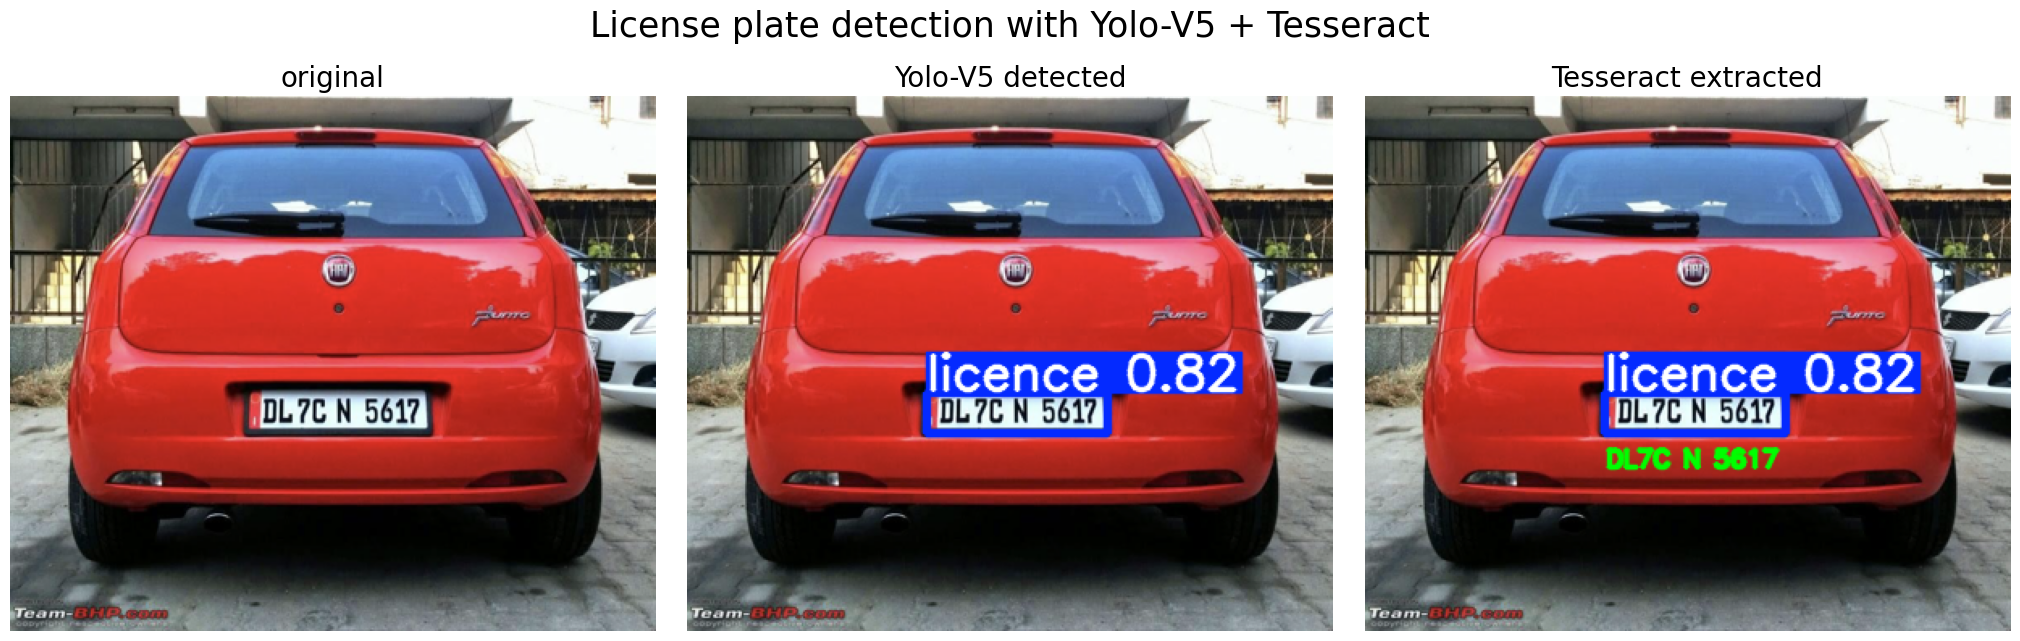

In [44]:
import cv2

for i, row in pred.pandas().xyxy[0].iterrows():
    if row['confidence'] < yolov5.conf: break
    print(row)

font = cv2.FONT_HERSHEY_SIMPLEX
# Blue color in BGR
color = (0, 255, 0)
# fontScale
fontScale = 0.5  
# Line thickness of 2 px
thickness = 2
# Using cv2.putText() method
img1 = np.asarray(Image.open('runs/detect/exp2/car.png'))
img2 = img1.copy()
if text and len(text) > 0:
    print(row['xmin'])
    cv2.putText(img2, "".join(e for e in text if e.isalnum() or e == ' ').strip(), (int(row['xmin']), int(row['ymax']+20)), font, fontScale, color, thickness, cv2.LINE_AA)
plt.figure(figsize=(20,7))
plt.subplots_adjust(0,0,1,0.95,0.05,0.05)
plt.subplot(131), plt.imshow(img), plt.axis('off'), plt.title('original', size=20)
plt.subplot(132), plt.imshow(img1), plt.axis('off'), plt.title('Yolo-V5 detected', size=20)
plt.subplot(133), plt.imshow(img2), plt.axis('off'), plt.title('Tesseract extracted', size=20)
plt.suptitle('License plate detection with Yolo-V5 + Tesseract', size=25)
plt.show()

### with easyocr

Htt 0.005853764801578498
@L7C N 5617 0.4067247441771556


(<matplotlib.image.AxesImage at 0x1a29cc80e10>,
 Text(0.5, 1.0, 'EasyOCR Plate Detection'),
 (np.float64(-0.5), np.float64(399.5), np.float64(331.5), np.float64(-0.5)))

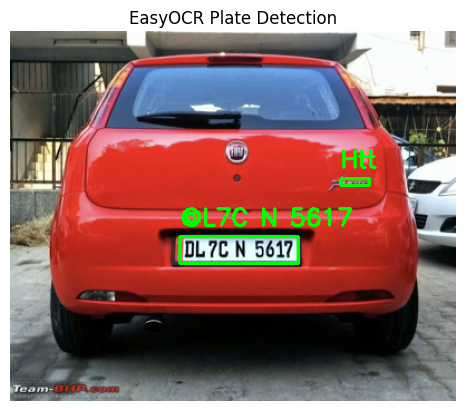

In [12]:
import easyocr

reader = easyocr.Reader(['en'])
img = cv2.imread("images/car.png")
results = reader.readtext(img)

for (bbox, text, prob) in results:
    print(text, prob)
    (tl, tr, br, bl) = bbox
    x1, y1 = map(int, tl)
    x2, y2 = map(int, br)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(img, text, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title("EasyOCR Plate Detection"), plt.axis('off')

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


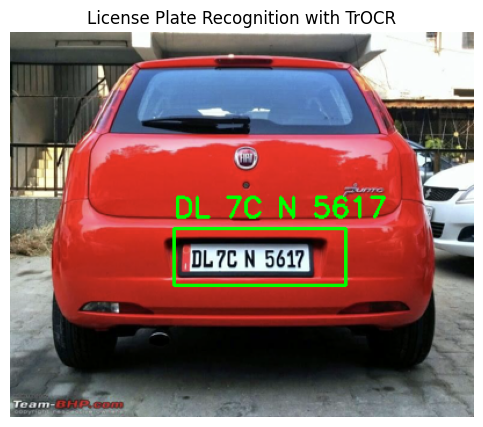


Detected Plates:
DL 7C N 5617


In [15]:
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Load TrOCR
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")

model.eval()

# Load Image
img_path = "images/car.png"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect License Plate (OpenCV)
plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_russian_plate_number.xml"
)

plates = plate_cascade.detectMultiScale(gray, 1.1, 5)

results_text = []

# Process Each Plate
for (x, y, w, h) in plates:
    plate = img_rgb[y:y+h, x:x+w]

    pil_img = Image.fromarray(plate)

    # Preprocess for TrOCR
    pixel_values = processor(images=pil_img, return_tensors="pt").pixel_values

    # Inference
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    results_text.append((text, (x, y, w, h)))

    # Draw box + text
    cv2.rectangle(img_rgb, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.putText(img_rgb, text, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

# Visualization
plt.figure(figsize=(10,5))
plt.imshow(img_rgb)
plt.title("License Plate Recognition with TrOCR")
plt.axis("off")
plt.show()

# Print Results
print("\nDetected Plates:")
for t, _ in results_text:
    print(t)

### Snapchat Filters with mediapipe

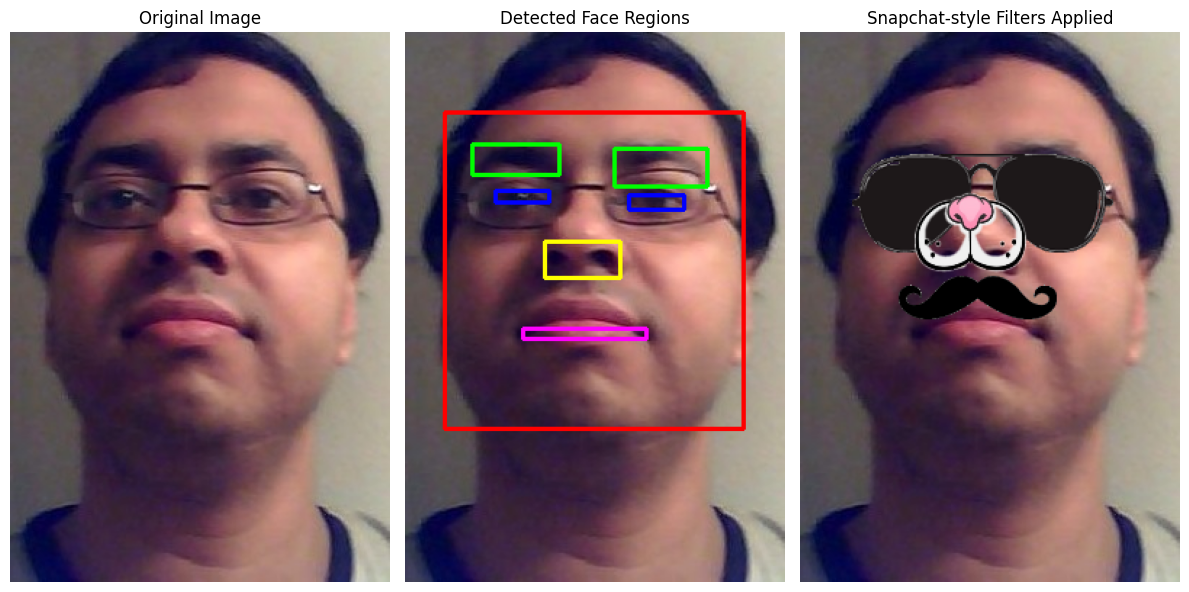

In [18]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pylab as plt

class SnapchatFiltersTasks:
    def __init__(self, model_path='face_landmarker.task'):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceLandmarkerOptions(
            base_options=base_options,
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=True,
            num_faces=1)
        self.detector = vision.FaceLandmarker.create_from_options(options)

    def overlay_png(self, frame, overlay, x, y, w, h):
        if w <= 0 or h <= 0:
            return frame

        overlay_resized = cv2.resize(overlay, (int(w), int(h)))

        h_img, w_img = frame.shape[:2]
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(w_img, x + int(w))
        y2 = min(h_img, y + int(h))

        overlay_x1 = 0 if x >= 0 else -x
        overlay_y1 = 0 if y >= 0 else -y
        overlay_x2 = overlay_x1 + (x2 - x1)
        overlay_y2 = overlay_y1 + (y2 - y1)

        if x2 <= x1 or y2 <= y1:
            return frame

        overlay_chunk = overlay_resized[overlay_y1:overlay_y2, overlay_x1:overlay_x2]

        alpha = overlay_chunk[:, :, 3] / 255.0
        inv_alpha = 1.0 - alpha

        for c in range(3):
            frame[y1:y2, x1:x2, c] = (
                alpha * overlay_chunk[:, :, c] +
                inv_alpha * frame[y1:y2, x1:x2, c]
            )

        return frame

    def apply_filters(self, frame, glasses, moustache, nose_img=None, ears=None):
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
        result = self.detector.detect(mp_image)

        if result.face_landmarks:
            for face_landmarks in result.face_landmarks:
                h, w, _ = frame.shape

                # 😎 Sunglasses
                left_eye = face_landmarks[33]
                right_eye = face_landmarks[263]

                lx, ly = int(left_eye.x * w), int(left_eye.y * h)
                rx, ry = int(right_eye.x * w), int(right_eye.y * h)

                glass_w = int(1.4 * abs(rx - lx))
                glass_h = int(glass_w * glasses.shape[0] / glasses.shape[1])

                gx = int((lx + rx) / 2 - glass_w / 2)
                gy = int((ly + ry) / 2 - glass_h / 2)

                frame = self.overlay_png(frame, glasses, gx, gy, glass_w, glass_h)

                # 👨 Moustache
                nose = face_landmarks[1]
                mouth_left = face_landmarks[61]
                mouth_right = face_landmarks[291]

                nx, ny = int(nose.x * w), int(nose.y * h)
                mlx, mly = int(mouth_left.x * w), int(mouth_left.y * h)
                mrx, mry = int(mouth_right.x * w), int(mouth_right.y * h)

                mous_w = int(1.3 * abs(mrx - mlx))
                mous_h = int(mous_w * moustache.shape[0] / moustache.shape[1])

                mx = int((mlx + mrx) / 2 - mous_w / 2)
                #my = int(ny + 5)
                lip_y = int((mly + mry) / 2)   # midpoint of lips
                my = int(ny + 0.4 * (lip_y - ny))  # 40% toward lips

                frame = self.overlay_png(frame, moustache, mx, my, mous_w, mous_h)

                # 🐻 Bunny Nose
                nose = face_landmarks[1]
                
                nx, ny = int(nose.x * w), int(nose.y * h)
                
                # 🔥 Use FACE WIDTH instead of small fraction
                left_eye = face_landmarks[33]
                right_eye = face_landmarks[263]
                
                lx = int(left_eye.x * w)
                rx = int(right_eye.x * w)
                
                face_width = abs(rx - lx) * 2   # approximate face width
                
                # 🔥 Increase size (tune this multiplier)
                nose_w = int(0.3 * face_width)   # try 0.3–0.45
                nose_h = int(nose_w * nose_img.shape[0] / nose_img.shape[1])
                
                # Center on nose
                nx = int(nx - nose_w / 2)
                ny = int(ny - nose_h / 2)
                
                frame = self.overlay_png(frame, nose_img, nx, ny, nose_w, nose_h)
               
        return frame

def draw_face_regions(frame, face_landmarks):
    img = frame.copy()
    h, w, _ = img.shape

    def get_box(indices, color):
        pts = np.array([[int(face_landmarks[i].x * w),
                         int(face_landmarks[i].y * h)] for i in indices])
        x, y, bw, bh = cv2.boundingRect(pts)
        cv2.rectangle(img, (x, y), (x + bw, y + bh), color, 2)

    # Region definitions (MediaPipe 468)
    LEFT_EYE = [33, 133, 160, 159, 158, 157, 173]
    RIGHT_EYE = [362, 263, 387, 386, 385, 384, 398]
    LEFT_EYEBROW = [70, 63, 105, 66, 107]
    RIGHT_EYEBROW = [336, 296, 334, 293, 300]
    NOSE = [1, 2, 98, 327]
    LIPS = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291]
    FACE = list(range(0, 468))

    # Draw rectangles
    get_box(LEFT_EYE, (255, 0, 0))       # Blue
    get_box(RIGHT_EYE, (255, 0, 0))
    get_box(LEFT_EYEBROW, (0, 255, 0))   # Green
    get_box(RIGHT_EYEBROW, (0, 255, 0))
    get_box(NOSE, (0, 255, 255))         # Yellow
    get_box(LIPS, (255, 0, 255))         # Magenta
    get_box(FACE, (0, 0, 255))           # Red

    return img
    
import cv2
import numpy as np

def remove_white_bg_keep_color(img_bgr, white_thresh=245, feather=3):
    """
    Convert a BGR image (with white background) to BGRA by removing near-white pixels.
    Keeps original colors; only background becomes transparent.

    white_thresh: 0–255. Higher = stricter 'white' detection (try 235–250).
    feather: blur radius for softer edges (0–5).
    """
    if img_bgr is None:
        return None

    # If already RGBA, just return
    if img_bgr.shape[2] == 4:
        return img_bgr

    img = img_bgr.astype(np.uint8)

    # Whiteness score: distance from pure white
    # small distance => close to white (background)
    diff = np.sqrt(((img.astype(np.float32) - 255.0) ** 2).sum(axis=2))

    # Normalize to [0,255]
    diff_norm = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Invert: white -> 0 alpha, colored -> 255 alpha
    alpha = cv2.threshold(diff_norm, white_thresh - 255, 255, cv2.THRESH_BINARY)[1]
    # The threshold above is a bit awkward due to normalization; simpler alternative:
    # alpha = (diff > (255 - white_thresh)).astype(np.uint8) * 255

    # Cleaner, simpler alpha:
    alpha = (diff > (255 - white_thresh)).astype(np.uint8) * 255

    # Optional edge cleanup
    if feather > 0:
        kernel = np.ones((3, 3), np.uint8)
        alpha = cv2.morphologyEx(alpha, cv2.MORPH_OPEN, kernel)
        alpha = cv2.GaussianBlur(alpha, (2 * feather + 1, 2 * feather + 1), 0)

    # Merge BGR + alpha
    b, g, r = cv2.split(img)
    rgba = cv2.merge([b, g, r, alpha])

    return rgba
    
# Load model
filter_app = SnapchatFiltersTasks('models/face_landmarker.task')

# Load images
frame = cv2.imread('images/me.png')
glasses = cv2.imread('images/sunglass.png', cv2.IMREAD_UNCHANGED)
moustache = cv2.imread('images/moustache.png', cv2.IMREAD_UNCHANGED)
nose_img = remove_white_bg_keep_color(cv2.imread('images/nose.png', cv2.IMREAD_UNCHANGED))

if frame is None:
    raise ValueError("Image not found")

# Detect landmarks ONCE
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
result = filter_app.detector.detect(mp_image)

# 1. Original
original = frame.copy()

# 2. Landmarks visualization
landmark_vis = frame.copy()

if result.face_landmarks:
    for face_landmarks in result.face_landmarks:
        landmark_vis = draw_face_regions(landmark_vis, face_landmarks)

# 3. Filtered output
output = filter_app.apply_filters(frame.copy(), glasses, moustache, nose_img)

# Plot side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(landmark_vis, cv2.COLOR_BGR2RGB))
plt.title("Detected Face Regions")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Snapchat-style Filters Applied")
plt.axis('off')

plt.tight_layout()
plt.show()